# Diabetes Prediction — End-to-End Machine Learning Project

**Dataset:** Pima Indians Diabetes Database (768 patients, 8 clinical features)  
**Task:** Binary classification — predict whether a patient has diabetes (`Outcome = 1`) or not (`Outcome = 0`)  
**Pipeline:** EDA → Preprocessing → Feature scaling → Model training → Evaluation → Serialisation

---

## 1. Imports

In [1]:
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("diabetes.csv")

print(f"Shape: {df.shape}")
print(f"\nClass balance:\n{df['Outcome'].value_counts()}")
print(f"\nPositive rate: {df['Outcome'].mean():.1%}")

Shape: (768, 9)

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64

Positive rate: 34.9%


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 3. Exploratory Data Analysis

Several columns use `0` as a placeholder for missing values (e.g. a BMI of 0 is physiologically impossible). We identify and handle these before modelling.

In [5]:
# Columns where 0 is not a valid measurement
zero_not_valid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count how many zeros exist in each column before replacement
zero_counts = (df[zero_not_valid] == 0).sum()
print("Zero counts (will be treated as missing):\n", zero_counts)

Zero counts (will be treated as missing):
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


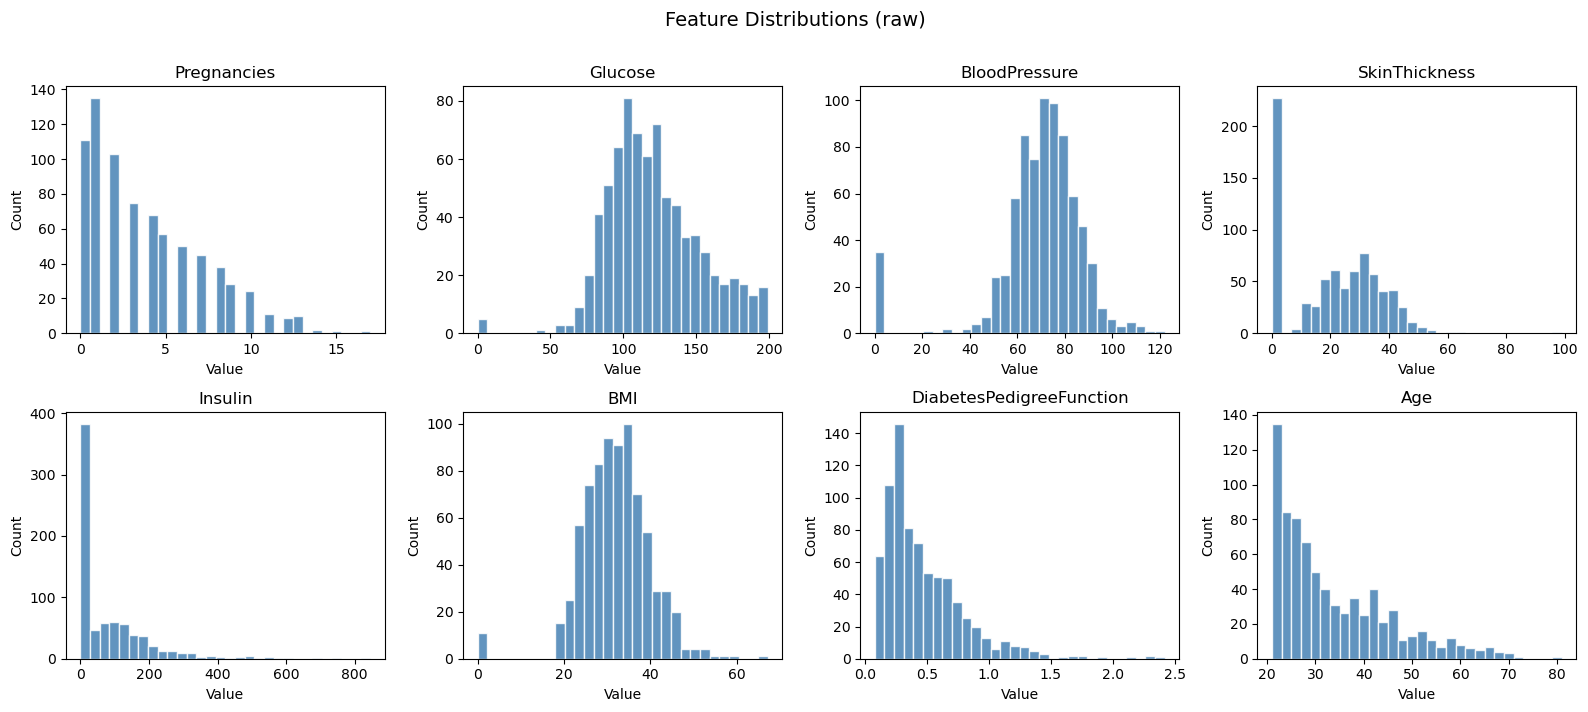

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    axes[i].hist(df[col], bins=30, edgecolor="white", color="steelblue", alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

fig.suptitle("Feature Distributions (raw)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Replace invalid zeros with `NaN`

In [7]:
df[zero_not_valid] = df[zero_not_valid].replace(0, np.nan)

print("Missing values after replacement:")
print(df.isna().sum())

Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 4.2 Impute missing values with the median

Median is preferred over mean here because `Insulin` and `SkinThickness` are right-skewed — the median is more robust to outliers.

In [8]:
for col in zero_not_valid:
    df[col] = df[col].fillna(df[col].median())

assert df.isna().sum().sum() == 0, "Imputation incomplete — nulls remain."
print("No missing values remain.")

No missing values remain.


## 5. Feature Engineering & Correlation Analysis

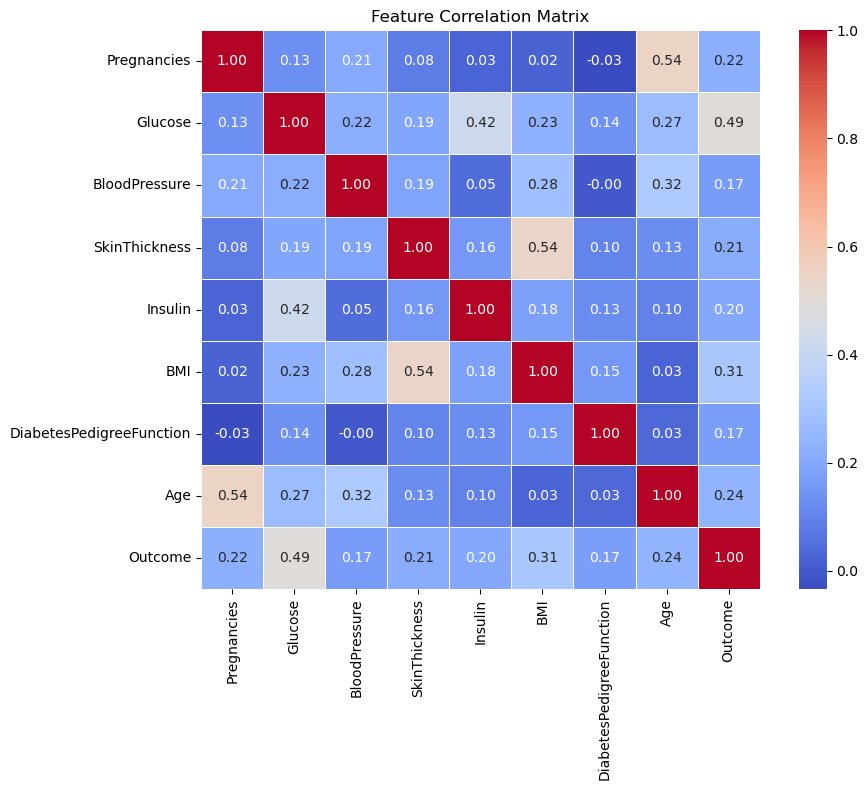

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Train / Validation / Test Split

`stratify=y` ensures the class ratio is preserved in every split.

In [10]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train size : 614 samples
Test size  : 154 samples

Train class balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Test class balance:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## 7. Baseline Model

Establish a naive baseline (majority-class predictor) before training real models. Any trained model should beat this.

In [11]:
majority_class = y_train.mode()[0]
baseline_accuracy = accuracy_score(y_test, [majority_class] * len(y_test))
print(f"Baseline accuracy (always predict '{majority_class}'): {baseline_accuracy:.3f}")

Baseline accuracy (always predict '0'): 0.649


## 8. Model Training

We use `sklearn.pipeline.Pipeline` to combine scaling and the classifier, which prevents data leakage — the scaler fits only on training data and is applied consistently at inference time.

### 8.1 Logistic Regression

In [12]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

print("Logistic Regression")
print(f"  Accuracy : {accuracy_score(y_test, lr_preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]):.3f}")

Logistic Regression
  Accuracy : 0.708
  ROC-AUC  : 0.813


### 8.2 Decision Tree — Hyperparameter Tuning with GridSearchCV

Note: this is a **classification** task, so we use `DecisionTreeClassifier` (not `DecisionTreeRegressor`) and an appropriate classification scoring metric.

In [13]:
dt_param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
}

dt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(random_state=42)),
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid_search = GridSearchCV(
    dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring="roc_auc",       # ROC-AUC is more informative than accuracy for imbalanced data
    n_jobs=-1,
    verbose=0,
)

dt_grid_search.fit(X_train, y_train)

print(f"Best parameters  : {dt_grid_search.best_params_}")
print(f"Best CV ROC-AUC  : {dt_grid_search.best_score_:.3f}")

Best parameters  : {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV ROC-AUC  : 0.778


In [14]:
best_dt_model = dt_grid_search.best_estimator_
dt_preds = best_dt_model.predict(X_test)

print("Decision Tree (tuned)")
print(f"  Accuracy : {accuracy_score(y_test, dt_preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1]):.3f}")

Decision Tree (tuned)
  Accuracy : 0.682
  ROC-AUC  : 0.816


## 9. Model Evaluation

We select the best-performing model and do a thorough evaluation on the held-out test set.

In [15]:
# Select the model with the higher test ROC-AUC
lr_auc = roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1])
dt_auc = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])

best_model = lr_pipeline if lr_auc >= dt_auc else best_dt_model
best_model_name = "Logistic Regression" if lr_auc >= dt_auc else "Decision Tree"
final_preds = best_model.predict(X_test)

print(f"Selected model: {best_model_name}")

Selected model: Decision Tree


In [16]:
print(classification_report(y_test, final_preds, target_names=["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.69      0.91      0.79       100
    Diabetes       0.61      0.26      0.36        54

    accuracy                           0.68       154
   macro avg       0.65      0.58      0.58       154
weighted avg       0.66      0.68      0.64       154



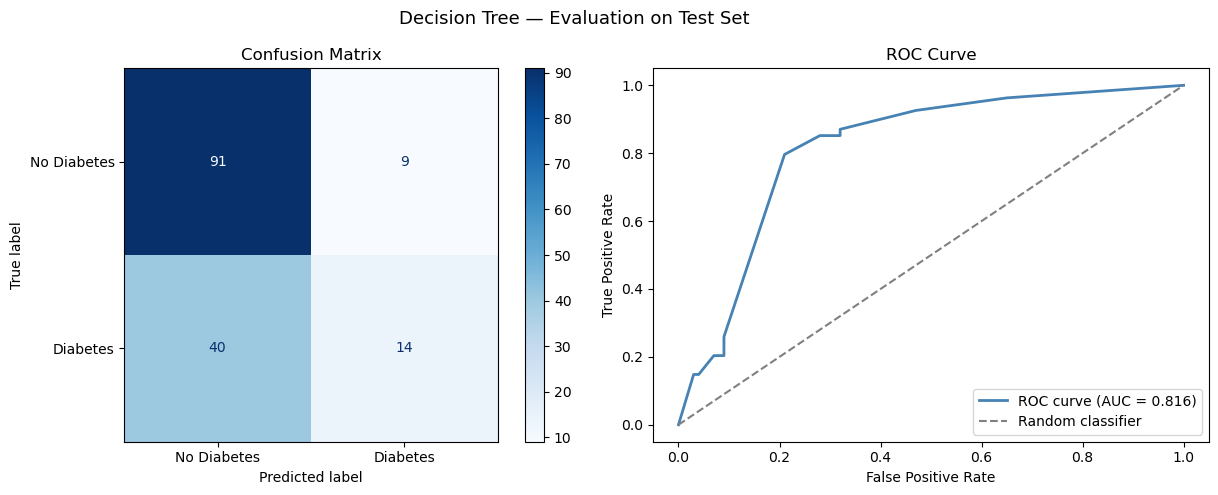

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds,
    display_labels=["No Diabetes", "Diabetes"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
auc_score = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.suptitle(f"{best_model_name} — Evaluation on Test Set", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Save the Model

We serialise the entire pipeline (scaler + classifier) so the same transformations are applied consistently at inference time.

In [18]:
model_path = "diabetes.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model saved to '{model_path}'")

Model saved to 'diabetes.pkl'


## 11. Inference — Single-Patient Prediction

Demonstrate how to load the saved model and make a prediction on a new patient.

In [19]:
# Load the saved model
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

# Example patient: [Pregnancies, Glucose, BloodPressure, SkinThickness,
#                   Insulin, BMI, DiabetesPedigreeFunction, Age]
new_patient = pd.DataFrame(
    [[6, 148, 72, 35, 0, 33.6, 0.627, 50]],
    columns=X.columns,
)

prediction = loaded_model.predict(new_patient)[0]
probability = loaded_model.predict_proba(new_patient)[0][1]

print(f"Prediction  : {'Diabetes' if prediction == 1 else 'No Diabetes'}")
print(f"Probability : {probability:.1%}")

Prediction  : No Diabetes
Probability : 48.7%


---

## Summary

| Step | Key decision |
|---|---|
| Missing values | Zeros replaced with `NaN`, imputed with column median |
| Splitting | 80/20 stratified split to preserve class balance |
| Scaling | `StandardScaler` inside a `Pipeline` to prevent data leakage |
| Models | Logistic Regression + Decision Tree with `GridSearchCV` |
| Tuning metric | ROC-AUC (more robust than accuracy for imbalanced classes) |
| Serialisation | Full pipeline pickled — scaler and classifier travel together |

**Next steps:**  
- Try ensemble methods (Random Forest, XGBoost) for higher performance  
- Address class imbalance with SMOTE or `class_weight='balanced'`  
- Add SHAP values for feature-level explainability